In [1355]:
import matplotlib.pyplot as plt
import numpy as np
import itertools
import pandas as pd

import read_write_info
import experiment_global_vars
import os
import pickle
from math import sqrt
from scipy.stats import norm


In [1356]:
print(f"Current dir: {os.getcwd()}")

Current dir: /Users/xueqingliu/Harvard University Dropbox/Liu Xueqing/budgeted_oral/src/experiments


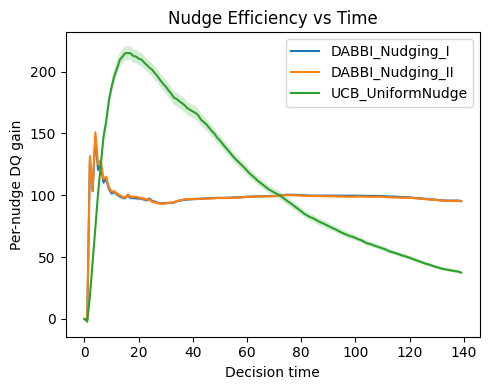

In [1357]:
# plot efficiency gain versus time
from numpy import mean

base_dir = '../../results04/eval_pooling/no_pooling_online_None'
algorithms = ['DABBI_Nudging_I', 'DABBI_Nudging_II', 'UCB_UniformNudge']

def load_efficiency_tensor(metrics_path):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    eff = metrics.get('nudge_efficiency', None)
    if eff is None:
        raise ValueError(f"Missing 'nudge_efficiency' in {metrics_path}")
    return np.asarray(eff)  # [seed, user, time]

# def mean_and_ci_95(eff_tensor):
#     if eff_tensor.ndim != 3:
#         raise ValueError('Expected tensor of shape [seed, user, time]')
#     S, U, T = eff.shape
#     eff_flat = eff.reshape(S * U, T)       # [S*U, T]

#     mean_series = eff_flat.mean(axis=0)    # mean over all seed-user obs
#     std_pooled = eff_flat.std(axis=0, ddof=1)
#     sem_pooled = std_pooled / np.sqrt(S * U)

#     z_crit = norm.ppf(0.975)  # ~1.96
#     ci_95 = z_crit * sem_pooled


#     print("S, U, S*U:", S, U, S*U)
#     print("median SEM pooled:", np.median(sem_pooled))

#     # If you still have seed-only SEM, compare:
#     eff_seed_mean = eff.mean(axis=1)  # [S, T]
#     sem_seeds = eff_seed_mean.std(axis=0, ddof=1) / np.sqrt(S)
#     print("median SEM seeds:", np.median(sem_seeds))
#     return mean_series, ci_95

def mean_and_ci_95(eff_tensor):
    # eff: [S, U, T]
    S, U, T = eff_tensor.shape
    
    # Average users within each seed first -> [S, T]
    eff_seed_mean = eff_tensor.mean(axis=1)
    mean_series = eff_seed_mean.mean(axis=0)
    
    # SEM across seeds (treating seeds as independent)
    std_seeds = eff_seed_mean.std(axis=0, ddof=1)
    sem_seeds = std_seeds / np.sqrt(S)
    
    # 95% CI
    ci_95 = 1.96 * sem_seeds
    return mean_series, ci_95

# def mean_and_ci_95(eff_tensor):
#     # eff_tensor: [num_seeds, num_users, num_times]
#     import numpy as np
#     if eff_tensor.ndim != 3:
#         raise ValueError("Expected tensor of shape [seed, user, time]")

#     # Per-user mean across seeds -> [num_users, num_times]
#     eff_user_mean = eff_tensor.mean(axis=0)

#     # Overall mean across users -> [num_times]
#     mean_series = eff_user_mean.mean(axis=0)

#     # SEM across users -> [num_times]
#     num_users = eff_user_mean.shape[0]
#     if num_users <= 1:
#         ci_95 = np.zeros_like(mean_series)
#     else:
#         std_users = eff_user_mean.std(axis=0, ddof=1)
#         sem_users = std_users / np.sqrt(num_users)
#         ci_95 = 1.96 * sem_users

#     return mean_series, ci_95

plt.figure(figsize=(5, 4))
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    eff = load_efficiency_tensor(metrics_path)
    mean_series, sem_series = mean_and_ci_95(eff)
    t = np.arange(len(mean_series))
    plt.plot(t, mean_series, label=alg)
    plt.fill_between(t, mean_series - sem_series, mean_series + sem_series, alpha=0.2)

plt.xlabel('Decision time')
plt.ylabel('Per-nudge DQ gain')
plt.title('Nudge Efficiency vs Time')
plt.legend()
plt.tight_layout()
plt.show()

Processing DABBI_Nudging_I...
Processing DABBI_Nudging_II...
Processing UCB_UniformNudge...
[ 0.00000000e+00 -9.34036263e-01  1.29082482e+02  1.99299421e+02
  3.07991688e+02  3.82918259e+02  4.54659669e+02  5.16796664e+02
  5.75869526e+02  6.32514359e+02  6.80769685e+02  7.35274478e+02
  7.57972062e+02  7.78232250e+02  7.92117815e+02  8.05989412e+02
  8.15288110e+02  8.23337230e+02  8.32927231e+02  8.40354591e+02
  8.43618748e+02  8.46834518e+02  8.51193475e+02  8.58968471e+02
  8.68122338e+02  8.75630717e+02  8.82396254e+02  8.86593501e+02
  8.90359609e+02  8.95120890e+02  9.00158418e+02  9.04909294e+02
  9.09769451e+02  9.13584157e+02  9.20553528e+02  9.27164964e+02
  9.34842866e+02  9.42523746e+02  9.48924286e+02  9.54159952e+02
  9.59918124e+02  9.64968774e+02  9.69210590e+02  9.72085567e+02
  9.75064215e+02  9.78200353e+02  9.79595372e+02  9.80538739e+02
  9.81217204e+02  9.81878815e+02  9.81738989e+02  9.82650966e+02
  9.83347811e+02  9.84034979e+02  9.84328225e+02  9.85944427e+0

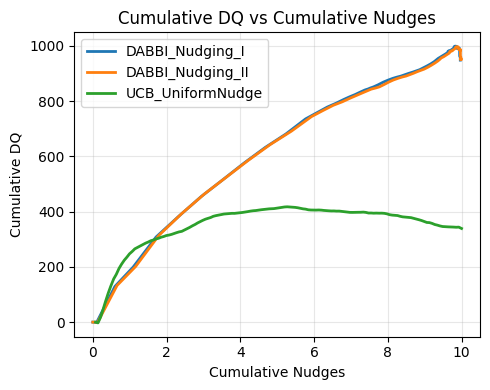

In [1358]:
# plot cumulative DQ versus cumulative nudge

def load_cumulative_metrics(metrics_path):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    
    # Get cumulative DQ and nudges from metrics
    total_dq_cum = metrics.get('total_dq_cum', None)
    total_nudges_cum = metrics.get('total_nudges_cum', None)
    
    if total_dq_cum is None or total_nudges_cum is None:
        raise ValueError(f"Missing cumulative data in {metrics_path}")
    
    return np.array(total_dq_cum), np.array(total_nudges_cum)

def aggregate_cumulative_seed_level(dq_cum, nudges_cum):
    """Aggregate cumulative trajectories at seed level (across users)"""
    # dq_cum, nudges_cum: [num_seeds, num_users, num_times]
    S, U, T = dq_cum.shape
    
    # Average across users for each seed -> [num_seeds, num_times]
    dq_seed_mean = dq_cum.mean(axis=1)
    nudges_seed_mean = nudges_cum.mean(axis=1)
    
    # Mean across seeds -> [num_times]
    mean_dq = dq_seed_mean.mean(axis=0)
    mean_nudges = nudges_seed_mean.mean(axis=0)
    
    # SEM across seeds
    num_seeds = dq_seed_mean.shape[0]

    std_dq = dq_seed_mean.std(axis=0, ddof=1)
    std_nudges = nudges_seed_mean.std(axis=0, ddof=1)
    sem_dq = std_dq / np.sqrt(num_seeds)
    sem_nudges = std_nudges / np.sqrt(num_seeds)
    
    # 95% CI
    ci_dq = 1.96 * sem_dq
    ci_nudges = 1.96 * sem_nudges

    
    return mean_dq, mean_nudges, ci_dq, ci_nudges

def plot_cumulative_dq_vs_nudges(alg_data):
    plt.figure(figsize=(5, 4))
    
    for alg_name, (mean_dq, mean_nudges, ci_dq, ci_nudges) in alg_data.items():
        # Plot mean trajectory
        print(mean_dq)
        plt.plot(mean_nudges, mean_dq, label=alg_name, linewidth=2)
        
        # Add confidence bands (using DQ uncertainty)
        # plt.fill_between(mean_nudges, 
        #                 mean_dq - ci_dq, 
        #                 mean_dq + ci_dq, 
        #                 alpha=0.2)
    
    plt.xlabel('Cumulative Nudges')
    plt.ylabel('Cumulative DQ')
    plt.title('Cumulative DQ vs Cumulative Nudges')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Main execution
alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    dq_cum, nudges_cum = load_cumulative_metrics(metrics_path)
    mean_dq, mean_nudges, ci_dq, ci_nudges = aggregate_cumulative_seed_level(dq_cum, nudges_cum)
    alg_data[alg] = (mean_dq, mean_nudges, ci_dq, ci_nudges)

plot_cumulative_dq_vs_nudges(alg_data)

Processing Cumulative DQ vs Time for DABBI_Nudging_I...
Processing Cumulative DQ vs Time for DABBI_Nudging_II...
Processing Cumulative DQ vs Time for UCB_UniformNudge...


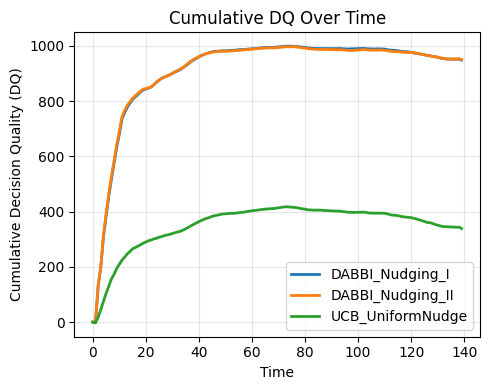

In [1359]:
def plot_cumulative_dq_vs_time(alg_data):
    """Plots Cumulative DQ versus Time steps."""
    plt.figure(figsize=(5, 4))
    
    for alg_name, (mean_dq, mean_nudges, ci_dq, ci_nudges) in alg_data.items():
        # *** KEY CHANGE: X-axis is time (index) ***
        t = np.arange(len(mean_dq)) 
        
        # Plot mean trajectory
        plt.plot(t, mean_dq, label=alg_name, linewidth=2)
        
        # Add confidence bands (using DQ uncertainty)
        # plt.fill_between(t, 
        #                 mean_dq - ci_dq, 
        #                 mean_dq + ci_dq, 
        #                 alpha=0.2)
    
    plt.xlabel('Time') # Updated X-label
    plt.ylabel('Cumulative Decision Quality (DQ)')
    plt.title('Cumulative DQ Over Time') # Updated Title
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Main execution for Cumulative DQ vs Time
if __name__ == '__main__':
    # We reuse the global 'algorithms' list defined near the top.
    
    dq_alg_data = {}
    for alg in algorithms:
        metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
        
        print(f"Processing Cumulative DQ vs Time for {alg}...")
        dq_cum, nudges_cum = load_cumulative_metrics(metrics_path)
        mean_dq, mean_nudges, ci_dq, ci_nudges = aggregate_cumulative_seed_level(dq_cum, nudges_cum)
        dq_alg_data[alg] = (mean_dq, mean_nudges, ci_dq, ci_nudges)

    plot_cumulative_dq_vs_time(dq_alg_data)

Processing Average DQ vs Time for DABBI_Nudging_I...
Processing Average DQ vs Time for DABBI_Nudging_II...
Processing Average DQ vs Time for UCB_UniformNudge...


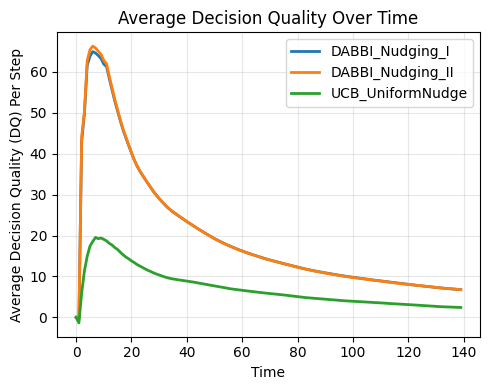

In [1360]:
def aggregate_average_dq_seed_level(dq_cum, nudges_cum):
    """Aggregate AVERAGE DQ per step trajectories at seed level (across users)"""
    # dq_cum, nudges_cum: [num_seeds, num_users, num_times]
    S, U, T = dq_cum.shape
    
    # --- KEY CHANGE: Normalize Cumulative DQ by time step (t) to get the running average ---
    time_steps = np.arange(1, T + 1)
    # Broadcasting handles the division across all seeds and users
    average_dq_tensor = dq_cum / time_steps
    # --------------------------------------------------------------------------------------
    
    # Average across users for each seed -> [num_seeds, num_times]
    dq_seed_mean = average_dq_tensor.mean(axis=1)
    
    # Mean across seeds -> [num_times]
    mean_avg_dq = dq_seed_mean.mean(axis=0)
    
    # SEM across seeds
    num_seeds = dq_seed_mean.shape[0]

    if num_seeds > 1:
        std_avg_dq = dq_seed_mean.std(axis=0, ddof=1)
        sem_avg_dq = std_avg_dq / np.sqrt(num_seeds)
        ci_avg_dq = 1.96 * sem_avg_dq
    else:
        ci_avg_dq = np.zeros_like(mean_avg_dq)
    
    # We return the mean cumulative nudges and its CI, though only mean_avg_dq and ci_avg_dq are used.
    # Note: Cumulative nudges are aggregated as before for consistency in the return signature.
    nudges_cum_mean = nudges_cum.mean(axis=1) 
    mean_nudges = nudges_cum_mean.mean(axis=0)
    std_nudges = nudges_cum_mean.std(axis=0, ddof=1) if num_seeds > 1 else np.zeros_like(mean_avg_dq)
    ci_nudges = 1.96 * (std_nudges / np.sqrt(num_seeds)) if num_seeds > 1 else np.zeros_like(mean_avg_dq)

    return mean_avg_dq, mean_nudges, ci_avg_dq, ci_nudges


# --- Plotting Function (Updated Title and Y-Label) ---

def plot_average_dq_vs_time(alg_data):
    """Plots Average DQ per Step versus Time steps."""
    plt.figure(figsize=(5, 4))
    
    # Note: We unpack the first and third returned values (mean_avg_dq, ci_avg_dq)
    for alg_name, (mean_avg_dq, _, ci_avg_dq, _) in alg_data.items():
        t = np.arange(len(mean_avg_dq)) 
        
        # Plot mean trajectory
        plt.plot(t, mean_avg_dq, label=alg_name, linewidth=2)
        
        # Add confidence bands (using DQ uncertainty)
        # plt.fill_between(t, 
        #                 mean_avg_dq - ci_avg_dq, 
        #                 mean_avg_dq + ci_avg_dq, 
        #                 alpha=0.2)
    
    plt.xlabel('Time')
    plt.ylabel('Average Decision Quality (DQ) Per Step') # <-- UPDATED LABEL
    plt.title('Average Decision Quality Over Time') # <-- UPDATED TITLE
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- Main Execution (Updated to call new aggregation and plotting functions) ---

if __name__ == '__main__':
    
    dq_alg_data = {}
    for alg in algorithms:
        metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
        
        print(f"Processing Average DQ vs Time for {alg}...")
        dq_cum, nudges_cum = load_cumulative_metrics(metrics_path)
        
        # *** KEY CHANGE: Calling the new Average DQ aggregation function ***
        mean_avg_dq, mean_nudges, ci_avg_dq, ci_nudges = aggregate_average_dq_seed_level(dq_cum, nudges_cum)
        dq_alg_data[alg] = (mean_avg_dq, mean_nudges, ci_avg_dq, ci_nudges)

    # *** KEY CHANGE: Calling the new Average DQ plotting function ***
    plot_average_dq_vs_time(dq_alg_data)

In [1361]:
algorithms = ['DABBI_Nudging_I', 'DABBI_Nudging_II', 'UCB_UniformNudge', 'UCB_NoNudge', 'UCB_NoReveal', 'UCB_NoNudge']

def load_quality_trajectories(metrics_path):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    
    quality_trajectories = metrics.get('quality_trajectories', None)
    if quality_trajectories is None:
        raise ValueError(f"Missing 'quality_trajectories' in {metrics_path}")
    
    return np.array(quality_trajectories)  # [num_seeds, num_users, num_times]



Processing DABBI_Nudging_I...
sem_average_quality: [2.23163225e-16 2.53103832e-03 3.78842185e-03 4.86418559e-03
 5.14377553e-03 5.23019574e-03 5.18967399e-03 5.23444754e-03
 5.20512544e-03 5.23042725e-03 5.21247121e-03 5.18396442e-03
 5.05517950e-03 4.95935216e-03 4.94658532e-03 4.89537108e-03
 4.85532430e-03 4.77333458e-03 4.70233737e-03 4.60527737e-03
 4.58939029e-03 4.53746084e-03 4.53633798e-03 4.47525343e-03
 4.36390396e-03 4.27038852e-03 4.18560763e-03 4.02963661e-03
 3.98966821e-03 3.89766189e-03 3.87304029e-03 3.82086196e-03
 3.82982669e-03 3.80545030e-03 3.81070039e-03 3.76265158e-03
 3.76227172e-03 3.71981411e-03 3.67158814e-03 3.58664637e-03
 3.54275580e-03 3.47173437e-03 3.47857573e-03 3.46179373e-03
 3.47099129e-03 3.44534762e-03 3.45874644e-03 3.44379581e-03
 3.45027650e-03 3.41566251e-03 3.41996885e-03 3.39454399e-03
 3.37263013e-03 3.32476004e-03 3.32745604e-03 3.29673657e-03
 3.30716612e-03 3.28958779e-03 3.30515001e-03 3.30682979e-03
 3.32043790e-03 3.30703980e-03 3.3

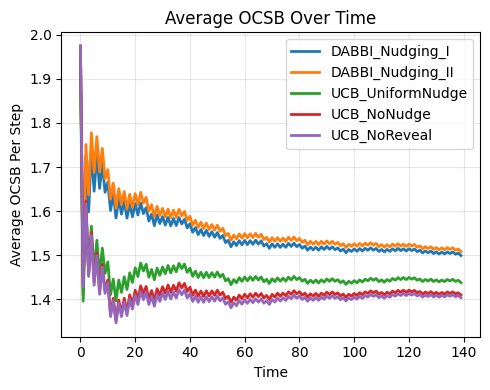

In [1362]:
def aggregate_average_quality_seed_level(quality_tensor):
    """Aggregate average quality trajectories at seed level (across users)"""
    # quality_tensor: [num_seeds, num_users, num_times]
    S, U, T = quality_tensor.shape
    
    # Compute cumulative sum for each user trajectory
    cumulative_quality = np.cumsum(quality_tensor, axis=2)  # [S, U, T]
    
    # --- NEW STEP: Normalize by time step (t) to get the running average ---
    time_steps = np.arange(1, T + 1)
    # Broadcasting handles the division across all seeds and users
    average_quality_tensor = cumulative_quality / time_steps
    # -----------------------------------------------------------------------
    
    # Average across users for each seed -> [num_seeds, num_times]
    average_quality_seed_mean = average_quality_tensor.mean(axis=1)
    
    # Mean across seeds -> [num_times]
    mean_average_quality = average_quality_seed_mean.mean(axis=0)
    
    # SEM across seeds
    num_seeds = average_quality_seed_mean.shape[0]
    if num_seeds > 1:
        std_average_quality = average_quality_seed_mean.std(axis=0, ddof=1)
        sem_average_quality = std_average_quality / np.sqrt(num_seeds)
        ci_average_quality = 1.96 * sem_average_quality
        print(f"sem_average_quality: {sem_average_quality}")
    else:
        ci_average_quality = np.zeros_like(mean_average_quality)
    
    return mean_average_quality, ci_average_quality


def plot_average_quality_trajectories(alg_data):
    plt.figure(figsize=(5, 4))
    
    for alg_name, (mean_avg_quality, ci_avg_quality) in alg_data.items():
        t = np.arange(len(mean_avg_quality))
        
        # Plot mean trajectory
        plt.plot(t, mean_avg_quality, label=alg_name, linewidth=2)
        
        # Add confidence bands
        # plt.fill_between(t, 
        #                 mean_avg_quality - ci_avg_quality, 
        #                 mean_avg_quality + ci_avg_quality, 
        #                 alpha=0.1)
    
    plt.xlabel('Time')
    plt.ylabel('Average OCSB Per Step') # <-- Updated Y-label
    plt.title('Average OCSB Over Time') # <-- Updated Title
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Assuming algorithms, load_quality_trajectories, os, pickle, plt, and np are defined

# Main execution
alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    quality_tensor = load_quality_trajectories(metrics_path)
    
    # --- CHANGE: Use the new aggregation function ---
    mean_avg_quality, ci_avg_quality = aggregate_average_quality_seed_level(quality_tensor)
    alg_data[alg] = (mean_avg_quality, ci_avg_quality)

# --- CHANGE: Use the new plotting function ---
plot_average_quality_trajectories(alg_data)

Calculating lift: DABBI_Nudging_II vs UCB_UniformNudge...
Top 10 Regret Gaps (UCB_UniformNudge Regret > DABBI_II Regret):
User 11: Regret Gap = 319.64
User 54: Regret Gap = 122.58
User 46: Regret Gap = 116.88
User 44: Regret Gap = 51.08
User 7: Regret Gap = 38.84
User 67: Regret Gap = 29.56
User 5: Regret Gap = 29.53
User 12: Regret Gap = 26.93
User 18: Regret Gap = 24.56
User 9: Regret Gap = 22.52
Processing DABBI_Nudging_I on high-lift users...
Processing DABBI_Nudging_II on high-lift users...
Processing UCB_UniformNudge on high-lift users...
Processing UCB_NoNudge on high-lift users...
Processing UCB_NoReveal on high-lift users...
Processing UCB_NoNudge on high-lift users...


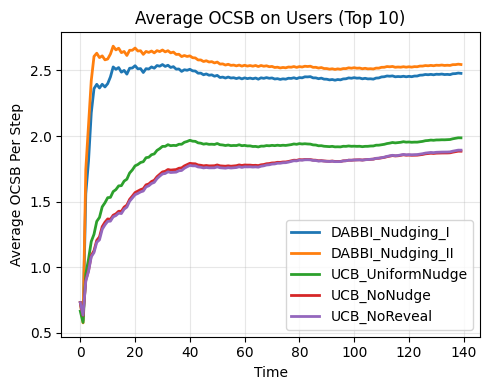

In [1363]:
def get_best_quality_user_indices(alg1_path, alg2_path, top_n=10):
    """
    Identifies indices of users where Alg1 (Primary) achieved the largest
    reduction in cumulative regret over Alg2 (Baseline).
    
    Gap = Cumulative Regret(Alg2) - Cumulative Regret(Alg1). 
    A larger positive gap means Alg1 is better.
    """
    # Load regret tensors
    r_tensor_1 = load_quality_trajectories(alg1_path) # DABBI_II
    r_tensor_2 = load_quality_trajectories(alg2_path) # UCB_UniformNudge
    
    if r_tensor_1.shape != r_tensor_2.shape:
        raise ValueError("Algorithm data shapes do not match! Cannot compare per-user.")
    
    # 1. Calculate final Cumulative Sums
    final_1 = np.cumsum(r_tensor_1, axis=2)[:, :, -1] # [num_seeds, num_users] (DABBI_II Regret)
    final_2 = np.cumsum(r_tensor_2, axis=2)[:, :, -1] # [num_seeds, num_users] (UCB_UniformNudge Regret)
    
    # 2. Average across seeds
    avg_final_1 = final_1.mean(axis=0) # [num_users]
    avg_final_2 = final_2.mean(axis=0) # [num_users]
    
    # 3. Calculate the Gap (Alg2 - Alg1). Positive = Alg1 is better (higher reward).
    reward_gap_scores = avg_final_1 - avg_final_2
    
    # 4. Get indices of the largest gaps (Top N)
    # argsort sorts low-to-high, so we take the last N and reverse
    sorted_indices = np.argsort(reward_gap_scores)
    best_reward_indices = sorted_indices[-top_n:][::-1]
        
    print(f"Top {top_n} Regret Gaps (UCB_UniformNudge Regret > DABBI_II Regret):")
    for i, idx in enumerate(best_reward_indices):
        print(f"User {idx}: Regret Gap = {reward_gap_scores[idx]:.2f}")
        
    return best_reward_indices

def aggregate_average_quality_seed_level(quality_tensor):
    """Aggregate average quality trajectories at seed level (across users)"""
    S, U, T = quality_tensor.shape
    cumulative_quality = np.cumsum(quality_tensor, axis=2)  # [S, U, T]
    
    # Normalize by time step (t) to get the running average
    time_steps = np.arange(1, T + 1)
    average_quality_tensor = cumulative_quality / time_steps
    
    average_quality_seed_mean = average_quality_tensor.mean(axis=1)
    mean_average_quality = average_quality_seed_mean.mean(axis=0)
    
    # Calculate CI/SEM (standard error of the mean)
    num_seeds = average_quality_seed_mean.shape[0]
    if num_seeds > 1:
        std_average_quality = average_quality_seed_mean.std(axis=0, ddof=1)
        sem_average_quality = std_average_quality / np.sqrt(num_seeds)
        ci_average_quality = 1.96 * sem_average_quality
    else:
        ci_average_quality = np.zeros_like(mean_average_quality)
    
    return mean_average_quality, ci_average_quality

def plot_average_quality_trajectories(alg_data, top_n_users, alg_primary, alg_baseline):
    plt.figure(figsize=(5, 4))
    
    for alg_name, (mean_avg_quality, ci_avg_quality) in alg_data.items():
        t = np.arange(len(mean_avg_quality))
        plt.plot(t, mean_avg_quality, label=alg_name, linewidth=2)
        # plt.fill_between(t, 
        #                 mean_avg_quality - ci_avg_quality, 
        #                 mean_avg_quality + ci_avg_quality, 
        #                 alpha=0.2)
    
    plt.xlabel('Time')
    plt.ylabel('Average OCSB Per Step')
    plt.title(f'Average OCSB on Users (Top {top_n_users})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Configuration for user selection
alg_primary = 'DABBI_Nudging_II'
alg_baseline = 'UCB_UniformNudge'
algorithms_to_plot = algorithms
top_n_users = 10

# Paths
path_primary = os.path.join(base_dir, f'{alg_primary}_comprehensive_metrics.p')
path_baseline = os.path.join(base_dir, f'{alg_baseline}_comprehensive_metrics.p')

# 1. Calculate the Best Lift Indices (UNCHANGED)
if os.path.exists(path_primary) and os.path.exists(path_baseline):
    print(f"Calculating lift: {alg_primary} vs {alg_baseline}...")
    target_indices = get_best_quality_user_indices(path_primary, path_baseline, top_n=top_n_users)
else:
    raise FileNotFoundError("One or both algorithm files not found.")

# 2. Process ALL algorithms using ONLY those users (AGGREGATION CHANGE)
alg_data = {}

for alg in algorithms_to_plot:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found")
        continue
    
    print(f"Processing {alg} on high-lift users...")
    
    full_quality = load_quality_trajectories(metrics_path)
    filtered_quality = full_quality[:, target_indices, :]
    
    # *** KEY CHANGE: Calling the average aggregation function ***
    mean_avg_quality, ci_avg_quality = aggregate_average_quality_seed_level(filtered_quality)
    alg_data[alg] = (mean_avg_quality, ci_avg_quality)

# 3. Plotting (PLOTTING FUNCTION CHANGE)
plot_average_quality_trajectories(alg_data, top_n_users, alg_primary, alg_baseline)



Calculating lift: DABBI_Nudging_II vs DABBI_Nudging_I...
Top 10 Regret Gaps (UCB_UniformNudge Regret > DABBI_II Regret):
User 44: Regret Gap = 78.93
User 54: Regret Gap = 36.06
User 21: Regret Gap = 18.18
User 43: Regret Gap = 11.77
User 0: Regret Gap = 9.23
User 18: Regret Gap = 8.31
User 37: Regret Gap = 6.31
User 39: Regret Gap = 4.16
User 46: Regret Gap = 2.55
User 16: Regret Gap = 2.43
Processing DABBI_Nudging_I on high-lift users...
Processing DABBI_Nudging_II on high-lift users...
Processing UCB_UniformNudge on high-lift users...
Processing UCB_NoNudge on high-lift users...
Processing UCB_NoReveal on high-lift users...
Processing UCB_NoNudge on high-lift users...


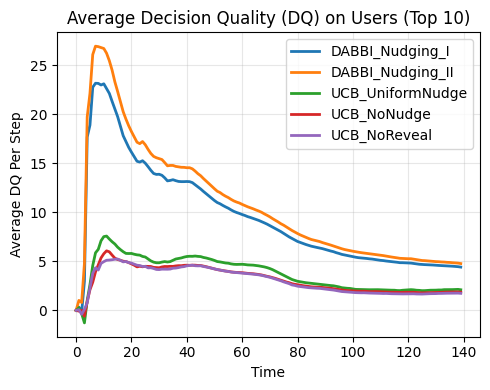

Processing DABBI_Nudging_I on high-lift users...
Processing DABBI_Nudging_II on high-lift users...
Processing UCB_UniformNudge on high-lift users...
Processing UCB_NoNudge on high-lift users...
Processing UCB_NoReveal on high-lift users...
Processing UCB_NoNudge on high-lift users...


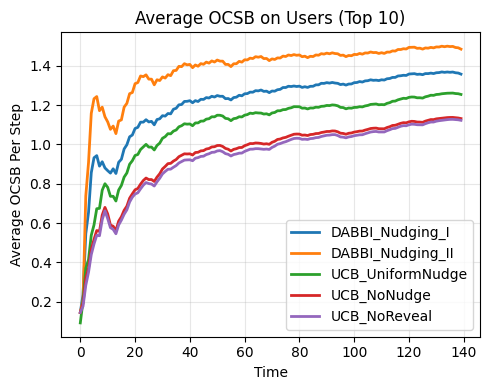

In [ ]:
# Configuration for user selection
alg_primary = 'DABBI_Nudging_II'
alg_baseline = 'DABBI_Nudging_I'
algorithms_to_plot = algorithms
top_n_users = 10

# Paths
path_primary = os.path.join(base_dir, f'{alg_primary}_comprehensive_metrics.p')
path_baseline = os.path.join(base_dir, f'{alg_baseline}_comprehensive_metrics.p')

# 1. Calculate the Best Lift Indices (UNCHANGED)
if os.path.exists(path_primary) and os.path.exists(path_baseline):
    print(f"Calculating lift: {alg_primary} vs {alg_baseline}...")
    target_indices = get_best_quality_user_indices(path_primary, path_baseline, top_n=top_n_users)
else:
    raise FileNotFoundError("One or both algorithm files not found.")

def plot_average_dq_vs_time(alg_data):
    """Plots Average DQ per Step versus Time steps."""
    plt.figure(figsize=(5, 4))
    
    # Note: We unpack the first and third returned values (mean_avg_dq, ci_avg_dq)
    for alg_name, (mean_avg_dq, _, ci_avg_dq, _) in alg_data.items():
        t = np.arange(len(mean_avg_dq)) 
        
        # Plot mean trajectory
        plt.plot(t, mean_avg_dq, label=alg_name, linewidth=2)
        
        # Add confidence bands (using DQ uncertainty)
        # plt.fill_between(t, 
        #                 mean_avg_dq - ci_avg_dq, 
        #                 mean_avg_dq + ci_avg_dq, 
        #                 alpha=0.2)
    
    plt.xlabel('Time')
    plt.ylabel('Average DQ Per Step') # <-- UPDATED LABEL
    plt.title('Average Decision Quality (DQ) on Users (Top 10)') # <-- UPDATED TITLE
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
if __name__ == '__main__':
    
    dq_alg_data = {}
    for alg in algorithms:
        metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
        if not os.path.exists(metrics_path):
            print(f"Skipping {alg}: not found")
            continue
        
        print(f"Processing {alg} on high-lift users...")
        dq_cum, nudges_cum = load_cumulative_metrics(metrics_path)
        filter_dq_cum = dq_cum[:, target_indices, :]
        filter_nudges_cum = nudges_cum[:, target_indices, :]
        
        mean_avg_dq, mean_nudges, ci_avg_dq, ci_nudges = aggregate_average_dq_seed_level(filter_dq_cum, filter_nudges_cum)
        dq_alg_data[alg] = (mean_avg_dq, mean_nudges, ci_avg_dq, ci_nudges)

    plot_average_dq_vs_time(dq_alg_data)
    
    alg_data = {}

for alg in algorithms_to_plot:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found")
        continue
    
    print(f"Processing {alg} on high-lift users...")
    
    full_quality = load_quality_trajectories(metrics_path)
    filtered_quality = full_quality[:, target_indices, :]
    
    # *** KEY CHANGE: Calling the average aggregation function ***
    mean_avg_quality, ci_avg_quality = aggregate_average_quality_seed_level(filtered_quality)
    alg_data[alg] = (mean_avg_quality, ci_avg_quality)

# 3. Plotting (PLOTTING FUNCTION CHANGE)

alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    regret_tensor = load_regret_trajectories(metrics_path)
    filter_regret_tensor = regret_tensor[:, target_indices, :]
    mean_cum_regret, ci_cum_regret = aggregate_cumulative_regret_seed_level(regret_tensor)
    alg_data[alg] = (mean_cum_regret, ci_cum_regret)

plot_cumulative_regret_trajectories(alg_data)


Processing DABBI_Nudging_I...
Processing DABBI_Nudging_II...
Processing UCB_UniformNudge...
Processing UCB_NoNudge...
Processing UCB_NoReveal...
Processing UCB_NoNudge...


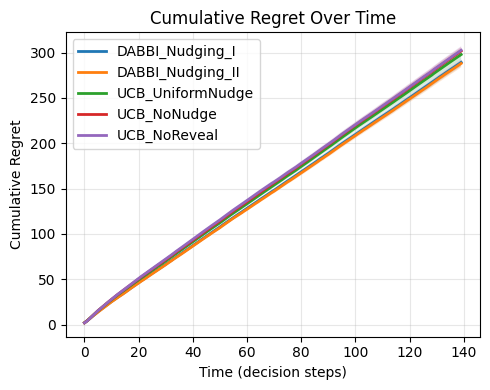

In [1366]:
def load_regret_trajectories(metrics_path):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    
    regret_trajectories = metrics.get('regret_trajectories', None)
    if regret_trajectories is None:
        raise ValueError(f"Missing 'regret_trajectories' in {metrics_path}")
    
    return np.array(regret_trajectories)  # [num_seeds, num_users, num_times]

def aggregate_cumulative_regret_seed_level(regret_tensor):
    """Aggregate cumulative regret trajectories at seed level (across users)"""
    # regret_tensor: [num_seeds, num_users, num_times]
    S, U, T = regret_tensor.shape
    
    # Compute cumulative sum for each user trajectory
    cumulative_regret = np.cumsum(regret_tensor, axis=2)  # [S, U, T]
    
    # Average across users for each seed -> [num_seeds, num_times]
    cumulative_regret_seed_mean = cumulative_regret.mean(axis=1)
    
    # Mean across seeds -> [num_times]
    mean_cumulative_regret = cumulative_regret_seed_mean.mean(axis=0)
    
    # SEM across seeds
    num_seeds = cumulative_regret_seed_mean.shape[0]
    if num_seeds > 1:
        std_cumulative_regret = cumulative_regret_seed_mean.std(axis=0, ddof=1)
        sem_cumulative_regret = std_cumulative_regret / np.sqrt(num_seeds)
        ci_cumulative_regret = 1.96 * sem_cumulative_regret
    else:
        ci_cumulative_regret = np.zeros_like(mean_cumulative_regret)
    
    return mean_cumulative_regret, ci_cumulative_regret

def plot_cumulative_regret_trajectories(alg_data):
    plt.figure(figsize=(5, 4))
    
    for alg_name, (mean_cum_regret, ci_cum_regret) in alg_data.items():
        t = np.arange(len(mean_cum_regret))
        
        # Plot mean trajectory
        plt.plot(t, mean_cum_regret, label=alg_name, linewidth=2)
        
        # Add confidence bands
        plt.fill_between(t, 
                        mean_cum_regret - ci_cum_regret, 
                        mean_cum_regret + ci_cum_regret, 
                        alpha=0.2)
    
    plt.xlabel('Time (decision steps)')
    plt.ylabel('Cumulative Regret')
    plt.title('Cumulative Regret Over Time')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Main execution
alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    regret_tensor = load_regret_trajectories(metrics_path)
    mean_cum_regret, ci_cum_regret = aggregate_cumulative_regret_seed_level(regret_tensor)
    alg_data[alg] = (mean_cum_regret, ci_cum_regret)

plot_cumulative_regret_trajectories(alg_data)


Processing DABBI_Nudging_I...
Processing DABBI_Nudging_II...
Processing UCB_UniformNudge...
Processing UCB_NoNudge...
Processing UCB_NoReveal...
Processing UCB_NoNudge...


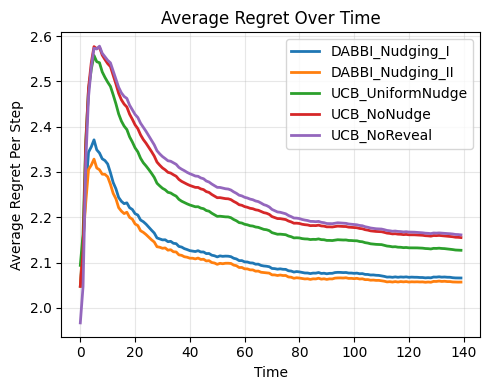

In [1367]:
def aggregate_average_regret_seed_level(regret_tensor):
    """Aggregate average regret trajectories at seed level (across users)"""
    # regret_tensor: [num_seeds, num_users, num_times]
    S, U, T = regret_tensor.shape
    
    # Compute cumulative sum for each user trajectory
    cumulative_regret = np.cumsum(regret_tensor, axis=2)  # [S, U, T]
    
    # --- NEW STEP: Normalize by time step (t) to get the running average ---
    time_steps = np.arange(1, T + 1)
    # Broadcasting handles the division across all seeds and users
    average_regret_tensor = cumulative_regret / time_steps
    # -----------------------------------------------------------------------
    
    # Average across users for each seed -> [num_seeds, num_times]
    average_regret_seed_mean = average_regret_tensor.mean(axis=1)
    
    # Mean across seeds -> [num_times]
    mean_average_regret = average_regret_seed_mean.mean(axis=0)
    
    # SEM across seeds
    num_seeds = average_regret_seed_mean.shape[0]
    if num_seeds > 1:
        std_average_regret = average_regret_seed_mean.std(axis=0, ddof=1)
        sem_average_regret = std_average_regret / np.sqrt(num_seeds)
        ci_average_regret = 1.96 * sem_average_regret
    else:
        ci_average_regret = np.zeros_like(mean_average_regret)
    
    return mean_average_regret, ci_average_regret

def plot_average_regret_trajectories(alg_data):
    plt.figure(figsize=(5, 4))
    
    for alg_name, (mean_avg_regret, ci_avg_regret) in alg_data.items():
        t = np.arange(len(mean_avg_regret))
        
        # Plot mean trajectory
        plt.plot(t, mean_avg_regret, label=alg_name, linewidth=2)
        
        # Add confidence bands
        # plt.fill_between(t, 
        #                 mean_avg_regret - ci_avg_regret, 
        #                 mean_avg_regret + ci_avg_regret, 
        #                 alpha=0.2)
    
    plt.xlabel('Time')
    plt.ylabel('Average Regret Per Step') # <-- Updated Y-label
    plt.title('Average Regret Over Time') # <-- Updated Title
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
# Main execution
alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    # Use the existing loading function
    regret_tensor = load_regret_trajectories(metrics_path)
    
    # --- CHANGE: Use the new average aggregation function ---
    mean_avg_regret, ci_avg_regret = aggregate_average_regret_seed_level(regret_tensor)
    alg_data[alg] = (mean_avg_regret, ci_avg_regret)

# --- CHANGE: Use the new average plotting function ---
plot_average_regret_trajectories(alg_data)

Filtering users based on Regret difference: DABBI_Nudging_II vs UCB_UniformNudge...
Top 10 Regret Gaps (UCB_UniformNudge Regret > DABBI_II Regret):
User 11: Regret Gap = 319.64
User 54: Regret Gap = 122.58
User 46: Regret Gap = 116.88
User 44: Regret Gap = 51.08
User 7: Regret Gap = 38.84
User 67: Regret Gap = 29.56
User 5: Regret Gap = 29.53
User 12: Regret Gap = 26.93
User 18: Regret Gap = 24.56
User 9: Regret Gap = 22.52
Processing DABBI_Nudging_I on Top 10 users...
Processing DABBI_Nudging_II on Top 10 users...
Processing UCB_UniformNudge on Top 10 users...
Processing UCB_NoNudge on Top 10 users...
Processing UCB_NoReveal on Top 10 users...
Processing UCB_NoNudge on Top 10 users...


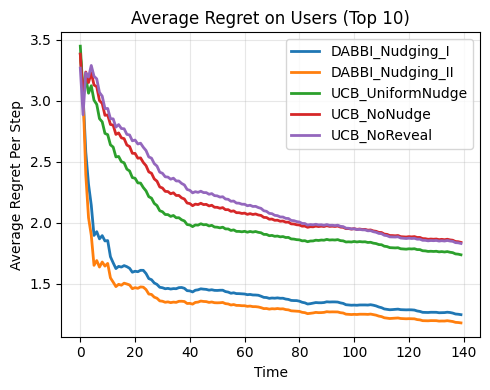

In [1368]:
# Placeholder function for loading regret (used for filtering and plotting)
def load_regret_trajectories(metrics_path):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    regret_trajectories = metrics.get('regret_trajectories', None)
    if regret_trajectories is None:
        raise ValueError(f"Missing 'regret_trajectories' in {metrics_path}")
    return np.array(regret_trajectories) # [num_seeds, num_users, num_times]
# --- End of placeholders ---


# --- 1. User Selection Logic (Filtering based on REGRET Gap) ---
def get_best_regret_user_indices(alg1_path, alg2_path, top_n=10):
    """
    Identifies indices of users where Alg1 (Primary) achieved the largest
    reduction in cumulative regret over Alg2 (Baseline).
    
    Gap = Cumulative Regret(Alg2) - Cumulative Regret(Alg1). 
    A larger positive gap means Alg1 is better.
    """
    # Load regret tensors
    r_tensor_1 = load_regret_trajectories(alg1_path) # DABBI_II
    r_tensor_2 = load_regret_trajectories(alg2_path) # UCB_UniformNudge
    
    if r_tensor_1.shape != r_tensor_2.shape:
        raise ValueError("Algorithm data shapes do not match! Cannot compare per-user.")
    
    # 1. Calculate final Cumulative Sums
    final_1 = np.cumsum(r_tensor_1, axis=2)[:, :, -1] # [num_seeds, num_users] (DABBI_II Regret)
    final_2 = np.cumsum(r_tensor_2, axis=2)[:, :, -1] # [num_seeds, num_users] (UCB_UniformNudge Regret)
    
    # 2. Average across seeds
    avg_final_1 = final_1.mean(axis=0) # [num_users]
    avg_final_2 = final_2.mean(axis=0) # [num_users]
    
    # 3. Calculate the Gap (Alg2 - Alg1). Positive = Alg1 is better (lower regret).
    regret_gap_scores = avg_final_2 - avg_final_1
    
    # 4. Get indices of the largest gaps (Top N)
    # argsort sorts low-to-high, so we take the last N and reverse
    sorted_indices = np.argsort(regret_gap_scores)
    best_regret_indices = sorted_indices[-top_n:][::-1]
        
    print(f"Top {top_n} Regret Gaps (UCB_UniformNudge Regret > DABBI_II Regret):")
    for i, idx in enumerate(best_regret_indices):
        print(f"User {idx}: Regret Gap = {regret_gap_scores[idx]:.2f}")
        
    return best_regret_indices

# --- 2. Average Regret Aggregation (Unchanged) ---
def aggregate_average_regret_seed_level(regret_tensor):
    """Aggregate average regret trajectories at seed level (across users)"""
    S, U, T = regret_tensor.shape
    
    cumulative_regret = np.cumsum(regret_tensor, axis=2)  # [S, U, T]
    
    # Normalize by time step (t) to get the running average
    time_steps = np.arange(1, T + 1)
    average_regret_tensor = cumulative_regret / time_steps
    
    average_regret_seed_mean = average_regret_tensor.mean(axis=1) # [num_seeds, num_times]
    mean_average_regret = average_regret_seed_mean.mean(axis=0) # [num_times]
    
    # SEM across seeds
    num_seeds = average_regret_seed_mean.shape[0]
    if num_seeds > 1:
        std_average_regret = average_regret_seed_mean.std(axis=0, ddof=1)
        sem_average_regret = std_average_regret / np.sqrt(num_seeds)
        ci_average_regret = 1.96 * sem_average_regret
    else:
        ci_average_regret = np.zeros_like(mean_average_regret)
    
    return mean_average_regret, ci_average_regret

# --- 3. Plotting Function for Subgroup Regret (Updated Title) ---
def plot_average_regret_trajectories_subgroup(alg_data, top_n_users, alg_primary, alg_baseline):
    plt.figure(figsize=(5, 4))
    
    for alg_name, (mean_avg_regret, ci_avg_regret) in alg_data.items():
        t = np.arange(len(mean_avg_regret))
        
        # Plot mean trajectory
        plt.plot(t, mean_avg_regret, label=alg_name, linewidth=2)
        
        # Add confidence bands (re-enabled for clarity)
        # plt.fill_between(t, 
        #                 mean_avg_regret - ci_avg_regret, 
        #                 mean_avg_regret + ci_avg_regret, 
        #                 alpha=0.2)
    
    plt.xlabel('Time')
    plt.ylabel('Average Regret Per Step')
    # Title updated to reflect regret gap filtering
    plt.title(f'Average Regret on Users (Top {top_n_users})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- 4. Main Execution (Updated Filtering Call) ---
if __name__ == '__main__':
    # Configuration
    alg_primary = 'DABBI_Nudging_II'
    alg_baseline = 'UCB_UniformNudge'
    algorithms_to_plot = algorithms
    top_n_users = 10

    # Paths
    path_primary = os.path.join(base_dir, f'{alg_primary}_comprehensive_metrics.p')
    path_baseline = os.path.join(base_dir, f'{alg_baseline}_comprehensive_metrics.p')

    # 1. Calculate the Best Lift Indices (based on REGRET)
    if os.path.exists(path_primary) and os.path.exists(path_baseline):
        print(f"Filtering users based on Regret difference: {alg_primary} vs {alg_baseline}...")
        # *** KEY CHANGE: Calling the regret-based filtering function ***
        target_indices = get_best_regret_user_indices(path_primary, path_baseline, top_n=top_n_users)
    else:
        # Create dummy data if files are missing for demonstration/testing
        print("Warning: Metrics files not found. Generating dummy data for plotting demonstration.")
        num_seeds, num_users, num_times = 5, 72, 140
        target_indices = np.random.choice(num_users, top_n_users, replace=False)

    # 2. Process ALL algorithms using ONLY those users (Regret data)
    alg_data = {}

    for alg in algorithms_to_plot:
        metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
        

        regret_tensor = load_regret_trajectories(metrics_path)
  
            
        print(f"Processing {alg} on Top {top_n_users} users...")
        
        # Filter the regret tensor using the indices derived from the regret gap
        filtered_regret = regret_tensor[:, target_indices, :]
        
        # Aggregate the Average Regret
        mean_avg_regret, ci_avg_regret = aggregate_average_regret_seed_level(filtered_regret)
        alg_data[alg] = (mean_avg_regret, ci_avg_regret)

    # 3. Plotting
    plot_average_regret_trajectories_subgroup(alg_data, top_n_users, alg_primary, alg_baseline)

Calculating lift: DABBI_Nudging_II vs DABBI_Nudging_I...
Top 10 Regret Gaps (UCB_UniformNudge Regret > DABBI_II Regret):
User 44: Regret Gap = 78.93
User 54: Regret Gap = 36.06
User 21: Regret Gap = 18.18
User 43: Regret Gap = 11.77
User 0: Regret Gap = 9.23
User 18: Regret Gap = 8.31
User 37: Regret Gap = 6.31
User 39: Regret Gap = 4.16
User 46: Regret Gap = 2.55
User 16: Regret Gap = 2.43
Processing DABBI_Nudging_I on high-lift users...
Processing DABBI_Nudging_II on high-lift users...
Processing UCB_UniformNudge on high-lift users...
Processing UCB_NoNudge on high-lift users...
Processing UCB_NoReveal on high-lift users...


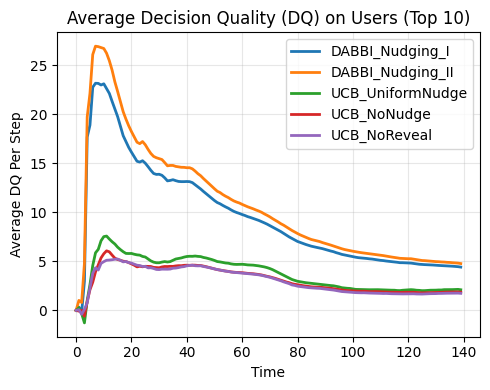

Processing DABBI_Nudging_I on high-lift users...
Processing DABBI_Nudging_II on high-lift users...
Processing UCB_UniformNudge on high-lift users...
Processing UCB_NoNudge on high-lift users...
Processing UCB_NoReveal on high-lift users...


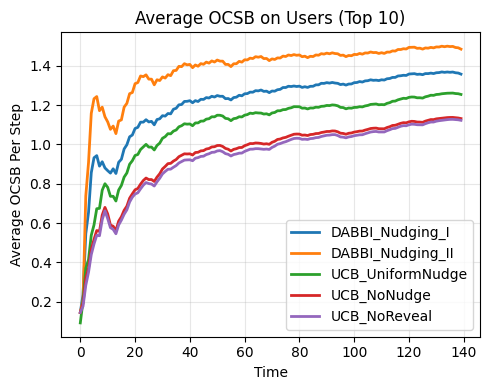

Processing DABBI_Nudging_I...
Processing DABBI_Nudging_II...
Processing UCB_UniformNudge...
Processing UCB_NoNudge...
Processing UCB_NoReveal...


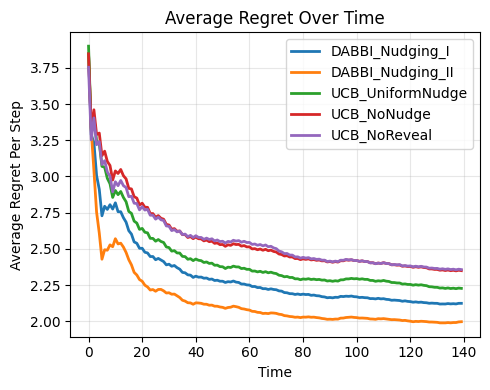

In [1379]:
# Configuration for user selection
alg_primary = 'DABBI_Nudging_II'
alg_baseline = 'DABBI_Nudging_I'
algorithms_to_plot = algorithms
top_n_users = 10

# Paths
path_primary = os.path.join(base_dir, f'{alg_primary}_comprehensive_metrics.p')
path_baseline = os.path.join(base_dir, f'{alg_baseline}_comprehensive_metrics.p')

# 1. Calculate the Best Lift Indices (UNCHANGED)
if os.path.exists(path_primary) and os.path.exists(path_baseline):
    print(f"Calculating lift: {alg_primary} vs {alg_baseline}...")
    target_indices = get_best_quality_user_indices(path_primary, path_baseline, top_n=top_n_users)
else:
    raise FileNotFoundError("One or both algorithm files not found.")

def plot_average_dq_vs_time(alg_data):
    """Plots Average DQ per Step versus Time steps."""
    plt.figure(figsize=(5, 4))
    
    # Note: We unpack the first and third returned values (mean_avg_dq, ci_avg_dq)
    for alg_name, (mean_avg_dq, _, ci_avg_dq, _) in alg_data.items():
        t = np.arange(len(mean_avg_dq)) 
        
        # Plot mean trajectory
        plt.plot(t, mean_avg_dq, label=alg_name, linewidth=2)
        
        # Add confidence bands (using DQ uncertainty)
        # plt.fill_between(t, 
        #                 mean_avg_dq - ci_avg_dq, 
        #                 mean_avg_dq + ci_avg_dq, 
        #                 alpha=0.2)
    
    plt.xlabel('Time')
    plt.ylabel('Average DQ Per Step') # <-- UPDATED LABEL
    plt.title('Average Decision Quality (DQ) on Users (Top 10)') # <-- UPDATED TITLE
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
if __name__ == '__main__':
    
    dq_alg_data = {}
    for alg in algorithms:
        metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
        if not os.path.exists(metrics_path):
            print(f"Skipping {alg}: not found")
            continue
        
        print(f"Processing {alg} on high-lift users...")
        dq_cum, nudges_cum = load_cumulative_metrics(metrics_path)
        filter_dq_cum = dq_cum[:, target_indices, :]
        filter_nudges_cum = nudges_cum[:, target_indices, :]
        
        mean_avg_dq, mean_nudges, ci_avg_dq, ci_nudges = aggregate_average_dq_seed_level(filter_dq_cum, filter_nudges_cum)
        dq_alg_data[alg] = (mean_avg_dq, mean_nudges, ci_avg_dq, ci_nudges)

    plot_average_dq_vs_time(dq_alg_data)
    
alg_data = {}

for alg in algorithms_to_plot:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found")
        continue
    
    print(f"Processing {alg} on high-lift users...")
    
    full_quality = load_quality_trajectories(metrics_path)
    filtered_quality = full_quality[:, target_indices, :]
    
    # *** KEY CHANGE: Calling the average aggregation function ***
    mean_avg_quality, ci_avg_quality = aggregate_average_quality_seed_level(filtered_quality)
    alg_data[alg] = (mean_avg_quality, ci_avg_quality)

plot_average_quality_trajectories(alg_data, top_n_users, alg_primary, alg_baseline)

# 3. Plotting (PLOTTING FUNCTION CHANGE)

alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    regret_tensor = load_regret_trajectories(metrics_path)
    filter_regret_tensor = regret_tensor[:, target_indices, :]
    mean_cum_regret, ci_cum_regret = aggregate_average_regret_seed_level(filter_regret_tensor)
    alg_data[alg] = (mean_cum_regret, ci_cum_regret)

plot_average_regret_trajectories(alg_data)


Calculating lift: DABBI_Nudging_II vs UCB_UniformNudge...
Top 10 Regret Gaps (UCB_UniformNudge Regret > DABBI_II Regret):
User 11: Regret Gap = 319.64
User 54: Regret Gap = 122.58
User 46: Regret Gap = 116.88
User 44: Regret Gap = 51.08
User 7: Regret Gap = 38.84
User 67: Regret Gap = 29.56
User 5: Regret Gap = 29.53
User 12: Regret Gap = 26.93
User 18: Regret Gap = 24.56
User 9: Regret Gap = 22.52
Processing DABBI_Nudging_I on high-lift users...
Processing DABBI_Nudging_II on high-lift users...
Processing UCB_UniformNudge on high-lift users...
Processing UCB_NoNudge on high-lift users...
Processing UCB_NoReveal on high-lift users...


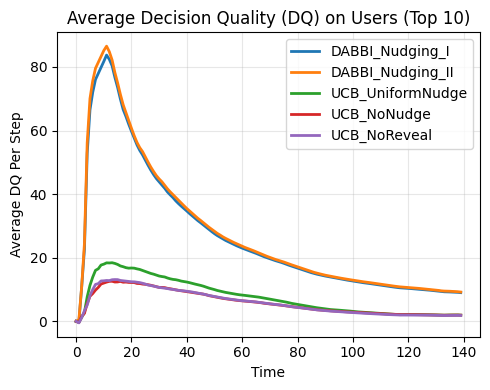

Processing DABBI_Nudging_I on high-lift users...
Processing DABBI_Nudging_II on high-lift users...
Processing UCB_UniformNudge on high-lift users...
Processing UCB_NoNudge on high-lift users...
Processing UCB_NoReveal on high-lift users...


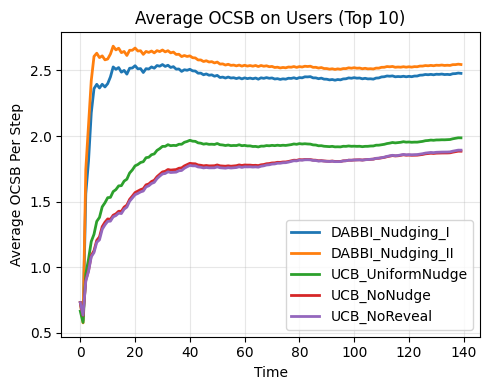

Processing DABBI_Nudging_I...
Processing DABBI_Nudging_II...
Processing UCB_UniformNudge...
Processing UCB_NoNudge...
Processing UCB_NoReveal...


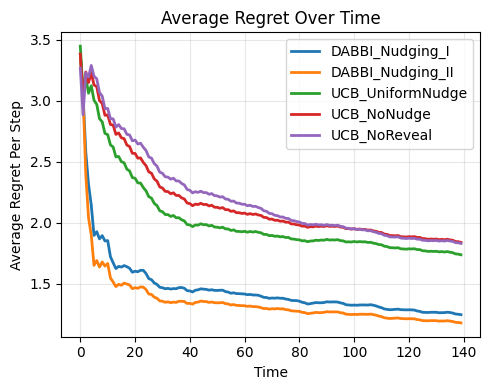

In [1380]:
# Configuration for user selection
alg_primary = 'DABBI_Nudging_II'
alg_baseline = 'UCB_UniformNudge'
algorithms_to_plot = algorithms
top_n_users = 10

# Paths
path_primary = os.path.join(base_dir, f'{alg_primary}_comprehensive_metrics.p')
path_baseline = os.path.join(base_dir, f'{alg_baseline}_comprehensive_metrics.p')

# 1. Calculate the Best Lift Indices (UNCHANGED)
if os.path.exists(path_primary) and os.path.exists(path_baseline):
    print(f"Calculating lift: {alg_primary} vs {alg_baseline}...")
    target_indices = get_best_quality_user_indices(path_primary, path_baseline, top_n=top_n_users)
else:
    raise FileNotFoundError("One or both algorithm files not found.")

def plot_average_dq_vs_time(alg_data):
    """Plots Average DQ per Step versus Time steps."""
    plt.figure(figsize=(5, 4))
    
    # Note: We unpack the first and third returned values (mean_avg_dq, ci_avg_dq)
    for alg_name, (mean_avg_dq, _, ci_avg_dq, _) in alg_data.items():
        t = np.arange(len(mean_avg_dq)) 
        
        # Plot mean trajectory
        plt.plot(t, mean_avg_dq, label=alg_name, linewidth=2)
        
        # Add confidence bands (using DQ uncertainty)
        # plt.fill_between(t, 
        #                 mean_avg_dq - ci_avg_dq, 
        #                 mean_avg_dq + ci_avg_dq, 
        #                 alpha=0.2)
    
    plt.xlabel('Time')
    plt.ylabel('Average DQ Per Step') # <-- UPDATED LABEL
    plt.title('Average Decision Quality (DQ) on Users (Top 10)') # <-- UPDATED TITLE
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
if __name__ == '__main__':
    
    dq_alg_data = {}
    for alg in algorithms:
        metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
        if not os.path.exists(metrics_path):
            print(f"Skipping {alg}: not found")
            continue
        
        print(f"Processing {alg} on high-lift users...")
        dq_cum, nudges_cum = load_cumulative_metrics(metrics_path)
        filter_dq_cum = dq_cum[:, target_indices, :]
        filter_nudges_cum = nudges_cum[:, target_indices, :]
        
        mean_avg_dq, mean_nudges, ci_avg_dq, ci_nudges = aggregate_average_dq_seed_level(filter_dq_cum, filter_nudges_cum)
        dq_alg_data[alg] = (mean_avg_dq, mean_nudges, ci_avg_dq, ci_nudges)

    plot_average_dq_vs_time(dq_alg_data)
    
alg_data = {}

for alg in algorithms_to_plot:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found")
        continue
    
    print(f"Processing {alg} on high-lift users...")
    
    full_quality = load_quality_trajectories(metrics_path)
    filtered_quality = full_quality[:, target_indices, :]
    
    # *** KEY CHANGE: Calling the average aggregation function ***
    mean_avg_quality, ci_avg_quality = aggregate_average_quality_seed_level(filtered_quality)
    alg_data[alg] = (mean_avg_quality, ci_avg_quality)

plot_average_quality_trajectories(alg_data, top_n_users, alg_primary, alg_baseline)

# 3. Plotting (PLOTTING FUNCTION CHANGE)

alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    regret_tensor = load_regret_trajectories(metrics_path)
    filter_regret_tensor = regret_tensor[:, target_indices, :]
    mean_cum_regret, ci_cum_regret = aggregate_average_regret_seed_level(filter_regret_tensor)
    alg_data[alg] = (mean_cum_regret, ci_cum_regret)

plot_average_regret_trajectories(alg_data)


Processing DABBI_Nudging_I...
Processing DABBI_Nudging_II...
Processing UCB_UniformNudge...


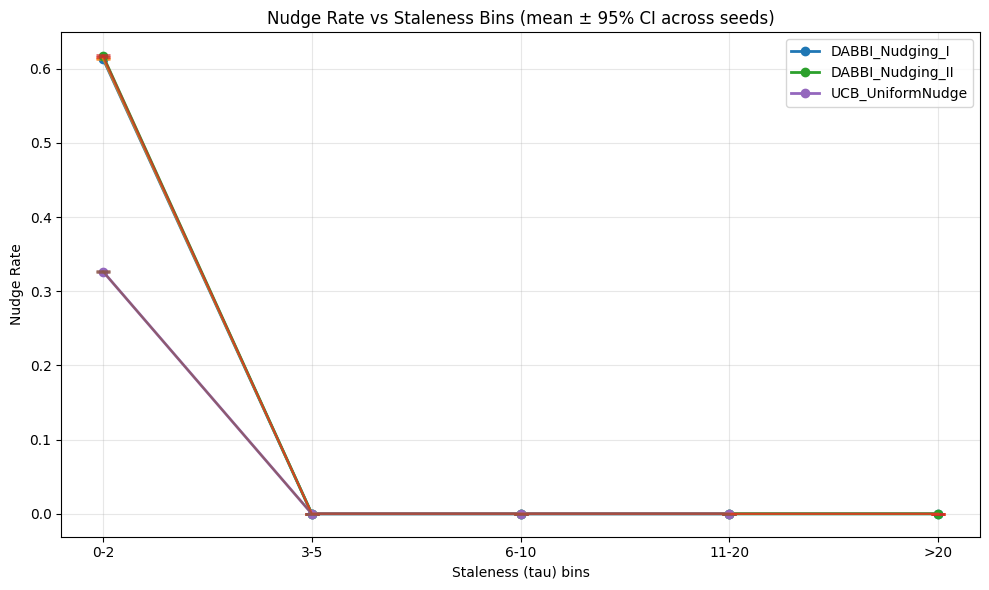

In [1369]:
# base_dir = '/tmp/budgeted_oral_results/eval_pooling/no_pooling_online_None'
algorithms = ['DABBI_Nudging_I', 'DABBI_Nudging_II', 'UCB_UniformNudge']

def load_metrics(metrics_path, metric_name):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    
    metric_data = metrics.get(metric_name, None)
    if metric_data is None:
        raise ValueError(f"Missing '{metric_name}' in {metrics_path}")
    
    return np.array(metric_data)

def aggregate_seed_level(metric_tensor):
    """Aggregate at seed level (across users)"""
    # metric_tensor: [num_seeds, num_users, num_bins]
    S, U, B = metric_tensor.shape
    
    # Average across users for each seed -> [num_seeds, num_bins]
    metric_seed_mean = metric_tensor.mean(axis=1)
    
    # Mean across seeds -> [num_bins]
    mean_metric = metric_seed_mean.mean(axis=0)
    
    # SEM across seeds
    num_seeds = metric_seed_mean.shape[0]
    if num_seeds > 1:
        std_metric = metric_seed_mean.std(axis=0, ddof=1)
        sem_metric = std_metric / np.sqrt(num_seeds)
        ci_metric = 1.96 * sem_metric
    else:
        ci_metric = np.zeros_like(mean_metric)
    
    return mean_metric, ci_metric

def plot_nudge_rates_vs_tau(alg_data):
    plt.figure(figsize=(10, 6))
    
    # Tau bin labels
    tau_labels = ["0-2", "3-5", "6-10", "11-20", ">20"]
    x_pos = np.arange(len(tau_labels))
    
    for alg_name, (mean_nudge_rate, ci_nudge_rate) in alg_data.items():
        plt.plot(x_pos, mean_nudge_rate, 'o-', label=alg_name, linewidth=2, markersize=6)
        plt.errorbar(x_pos, mean_nudge_rate, yerr=ci_nudge_rate, 
                    capsize=5, capthick=2, alpha=0.7)
    
    plt.xlabel('Staleness (tau) bins')
    plt.ylabel('Nudge Rate')
    plt.title('Nudge Rate vs Staleness Bins (mean ± 95% CI across seeds)')
    plt.xticks(x_pos, tau_labels)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Main execution
alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    nudge_rate_tensor = load_metrics(metrics_path, 'nudge_rate_by_tau')
    mean_nudge_rate, ci_nudge_rate = aggregate_seed_level(nudge_rate_tensor)
    alg_data[alg] = (mean_nudge_rate, ci_nudge_rate)

plot_nudge_rates_vs_tau(alg_data)

Processing DABBI_Nudging_I...
Processing DABBI_Nudging_II...
Processing UCB_UniformNudge...


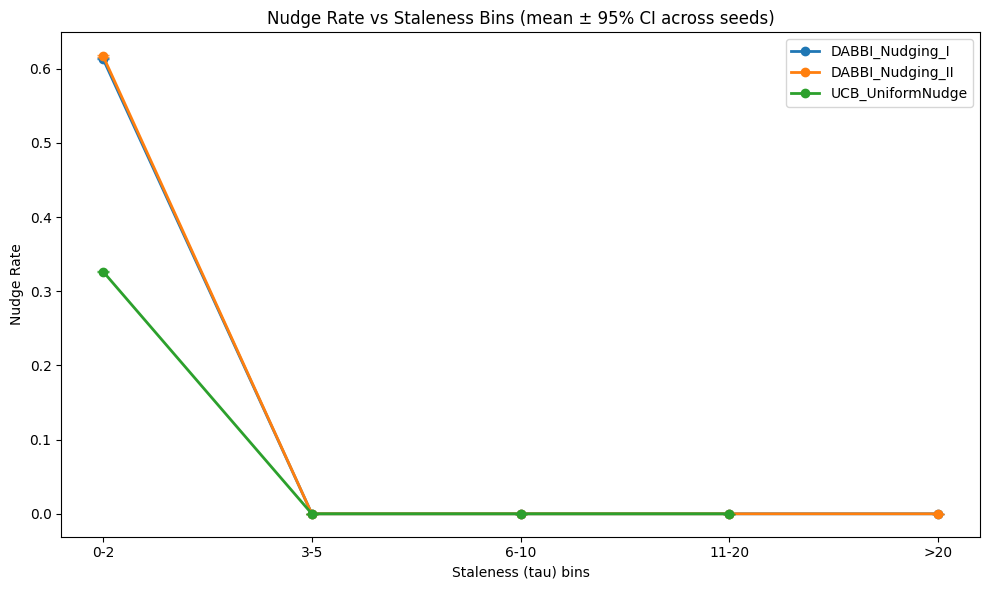

In [1370]:
# base_dir = '/tmp/budgeted_oral_results/eval_pooling/no_pooling_online_None'
algorithms = ['DABBI_Nudging_I', 'DABBI_Nudging_II', 'UCB_UniformNudge']

def load_metrics(metrics_path, metric_name):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    
    metric_data = metrics.get(metric_name, None)
    if metric_data is None:
        raise ValueError(f"Missing '{metric_name}' in {metrics_path}")
    
    return np.array(metric_data)

def aggregate_seed_level(metric_tensor):
    """Aggregate at seed level (across users)"""
    # metric_tensor: [num_seeds, num_users, num_bins]
    S, U, B = metric_tensor.shape
    
    # Average across users for each seed -> [num_seeds, num_bins]
    metric_seed_mean = metric_tensor.mean(axis=1)
    
    # Mean across seeds -> [num_bins]
    mean_metric = metric_seed_mean.mean(axis=0)
    
    # SEM across seeds
    num_seeds = metric_seed_mean.shape[0]
    if num_seeds > 1:
        std_metric = metric_seed_mean.std(axis=0, ddof=1)
        sem_metric = std_metric / np.sqrt(num_seeds)
        ci_metric = 1.96 * sem_metric
    else:
        ci_metric = np.zeros_like(mean_metric)
    
    return mean_metric, ci_metric

def plot_nudge_rates_vs_tau(alg_data):
    import matplotlib.pyplot as plt
    tau_labels = ["0-2", "3-5", "6-10", "11-20", ">20"]
    x_pos = np.arange(len(tau_labels))

    plt.figure(figsize=(10,6))
    for alg_name, (mean_rate, ci_rate) in alg_data.items():
        line, = plt.plot(x_pos, mean_rate, 'o-', label=alg_name, linewidth=2, markersize=6)
        color = line.get_color()
        plt.errorbar(x_pos, mean_rate, yerr=ci_rate, fmt='none',
                     ecolor=color, elinewidth=1, capsize=4, alpha=0.8)

    plt.xlabel('Staleness (tau) bins')
    plt.ylabel('Nudge Rate')
    plt.title('Nudge Rate vs Staleness Bins (mean ± 95% CI across seeds)')
    plt.xticks(x_pos, tau_labels)
    plt.legend()
    plt.tight_layout()
    plt.show()
# Main execution
alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    nudge_rate_tensor = load_metrics(metrics_path, 'nudge_rate_by_tau')
    mean_nudge_rate, ci_nudge_rate = aggregate_seed_level(nudge_rate_tensor)
    alg_data[alg] = (mean_nudge_rate, ci_nudge_rate)

plot_nudge_rates_vs_tau(alg_data)

Processing DABBI_Nudging_I...
Processing DABBI_Nudging_II...
Processing UCB_UniformNudge...
Processing UCB_NoNudge...
Processing UCB_NoReveal...


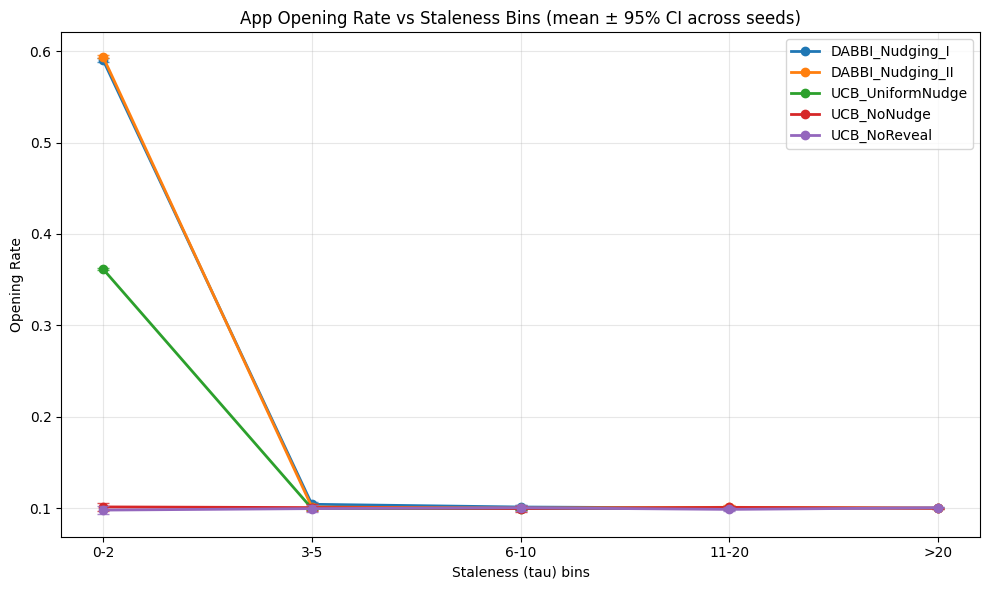

In [1371]:
algorithms = ['DABBI_Nudging_I', 'DABBI_Nudging_II', 'UCB_UniformNudge', 'UCB_NoNudge', 'UCB_NoReveal']

def load_metrics(metrics_path, metric_name):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    
    metric_data = metrics.get(metric_name, None)
    if metric_data is None:
        raise ValueError(f"Missing '{metric_name}' in {metrics_path}")
    
    return np.array(metric_data)

def aggregate_seed_level(metric_tensor):
    """Aggregate at seed level (across users)"""
    # metric_tensor: [num_seeds, num_users, num_bins]
    S, U, B = metric_tensor.shape
    
    # Average across users for each seed -> [num_seeds, num_bins]
    metric_seed_mean = metric_tensor.mean(axis=1)
    
    # Mean across seeds -> [num_bins]
    mean_metric = metric_seed_mean.mean(axis=0)
    
    # SEM across seeds
    num_seeds = metric_seed_mean.shape[0]
    if num_seeds > 1:
        std_metric = metric_seed_mean.std(axis=0, ddof=1)
        sem_metric = std_metric / np.sqrt(num_seeds)
        ci_metric = 1.96 * sem_metric
    else:
        ci_metric = np.zeros_like(mean_metric)
    
    return mean_metric, ci_metric

def plot_open_rates_vs_tau(alg_data):
    tau_labels = ["0-2", "3-5", "6-10", "11-20", ">20"]
    x_pos = np.arange(len(tau_labels))

    plt.figure(figsize=(10,6))
    for alg_name, (mean_rate, ci_rate) in alg_data.items():
        line, = plt.plot(x_pos, mean_rate, 'o-', label=alg_name, linewidth=2, markersize=6)
        color = line.get_color()
        plt.errorbar(x_pos, mean_rate, yerr=ci_rate, fmt='none',
                     ecolor=color, elinewidth=1, capsize=4, alpha=0.8)

    plt.xlabel('Staleness (tau) bins')
    plt.ylabel('Opening Rate')
    plt.title('App Opening Rate vs Staleness Bins (mean ± 95% CI across seeds)')
    plt.xticks(x_pos, tau_labels)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Main execution
alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    open_rate_tensor = load_metrics(metrics_path, 'open_rate_by_tau')
    mean_open_rate, ci_open_rate = aggregate_seed_level(open_rate_tensor)
    alg_data[alg] = (mean_open_rate, ci_open_rate)

plot_open_rates_vs_tau(alg_data)

Processing DABBI_Nudging_I...
Processing DABBI_Nudging_II...
Processing UCB_UniformNudge...
Processing UCB_NoNudge...
Processing UCB_NoReveal...


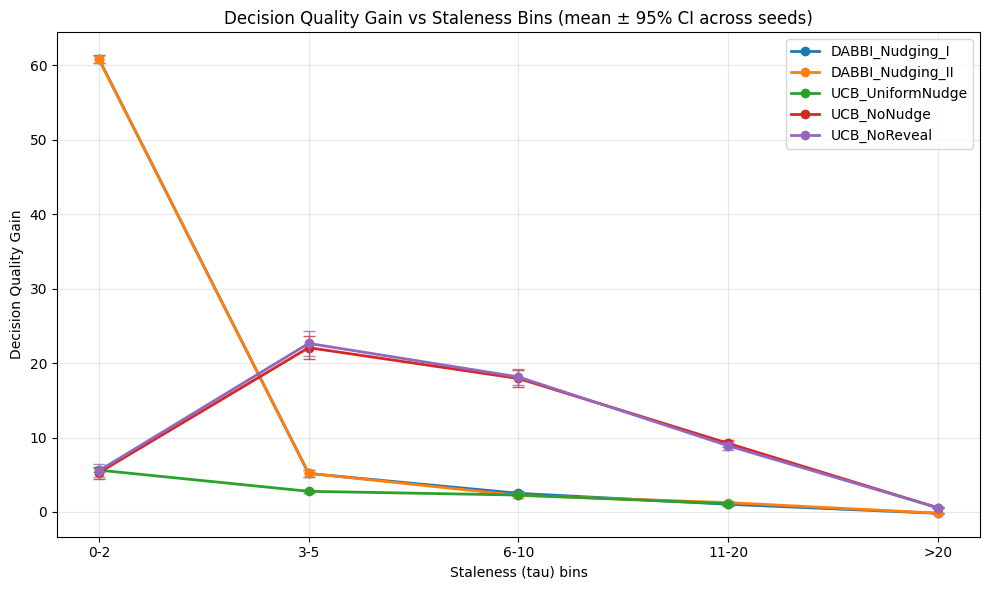

In [1372]:
import os, pickle, numpy as np
import matplotlib.pyplot as plt

# base_dir = '/tmp/budgeted_oral_results/eval_pooling/no_pooling_online_None'
algorithms = ['DABBI_Nudging_I', 'DABBI_Nudging_II', 'UCB_UniformNudge', 'UCB_NoNudge', 'UCB_NoReveal']

def load_metrics(metrics_path, metric_name):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    
    metric_data = metrics.get(metric_name, None)
    if metric_data is None:
        raise ValueError(f"Missing '{metric_name}' in {metrics_path}")
    
    return np.array(metric_data)

def aggregate_seed_level(metric_tensor):
    """Aggregate at seed level (across users)"""
    # metric_tensor: [num_seeds, num_users, num_bins]
    S, U, B = metric_tensor.shape
    
    # Average across users for each seed -> [num_seeds, num_bins]
    metric_seed_mean = metric_tensor.mean(axis=1)
    
    # Mean across seeds -> [num_bins]
    mean_metric = metric_seed_mean.mean(axis=0)
    
    # SEM across seeds
    num_seeds = metric_seed_mean.shape[0]
    if num_seeds > 1:
        std_metric = metric_seed_mean.std(axis=0, ddof=1)
        sem_metric = std_metric / np.sqrt(num_seeds)
        ci_metric = 1.96 * sem_metric
    else:
        ci_metric = np.zeros_like(mean_metric)
    
    return mean_metric, ci_metric

def plot_dq_gain_vs_tau(alg_data):
    tau_labels = ["0-2", "3-5", "6-10", "11-20", ">20"]
    x_pos = np.arange(len(tau_labels))

    plt.figure(figsize=(10,6))
    for alg_name, (mean_dq, ci_dq) in alg_data.items():
        line, = plt.plot(x_pos, mean_dq, 'o-', label=alg_name, linewidth=2, markersize=6)
        color = line.get_color()
        plt.errorbar(x_pos, mean_dq, yerr=ci_dq, fmt='none',
                     ecolor=color, elinewidth=1, capsize=4, alpha=0.8)

    plt.xlabel('Staleness (tau) bins')
    plt.ylabel('Decision Quality Gain')
    plt.title('Decision Quality Gain vs Staleness Bins (mean ± 95% CI across seeds)')
    plt.xticks(x_pos, tau_labels)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Main execution
alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    dq_gain_tensor = load_metrics(metrics_path, 'dq_gain_by_tau')
    mean_dq_gain, ci_dq_gain = aggregate_seed_level(dq_gain_tensor)
    alg_data[alg] = (mean_dq_gain, ci_dq_gain)

plot_dq_gain_vs_tau(alg_data)

Processing DABBI_Nudging_I...
Processing DABBI_Nudging_II...
Processing UCB_UniformNudge...
Processing UCB_NoNudge...


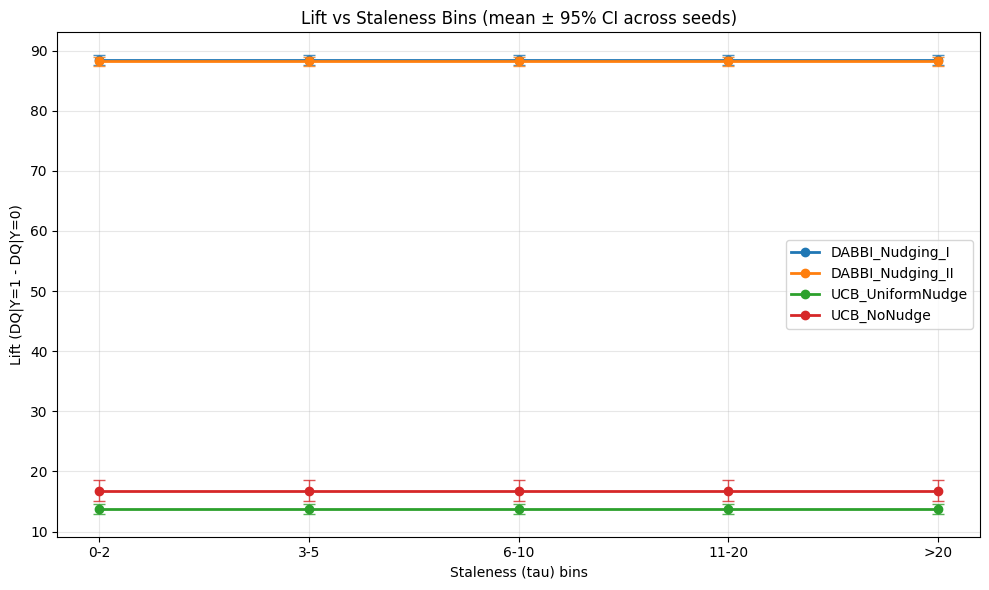

In [1373]:
algorithms = ['DABBI_Nudging_I', 'DABBI_Nudging_II', 'UCB_UniformNudge', 'UCB_NoNudge']
# , 'UCB_NoReveal']

def load_metrics(metrics_path, metric_name):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    
    metric_data = metrics.get(metric_name, None)
    if metric_data is None:
        raise ValueError(f"Missing '{metric_name}' in {metrics_path}")
    
    return np.array(metric_data)

def aggregate_seed_level(metric_tensor):
    """Aggregate at seed level (across users)"""
    # metric_tensor: [num_seeds, num_users, num_bins]
    S, U, B = metric_tensor.shape
    
    # Average across users for each seed -> [num_seeds, num_bins]
    metric_seed_mean = metric_tensor.mean(axis=1)
    
    # Mean across seeds -> [num_bins]
    mean_metric = metric_seed_mean.mean(axis=0)
    
    # SEM across seeds
    num_seeds = metric_seed_mean.shape[0]
    if num_seeds > 1:
        std_metric = metric_seed_mean.std(axis=0, ddof=1)
        sem_metric = std_metric / np.sqrt(num_seeds)
        ci_metric = 1.96 * sem_metric
    else:
        ci_metric = np.zeros_like(mean_metric)
    
    return mean_metric, ci_metric

def plot_lift_vs_tau(alg_data):
    tau_labels = ["0-2", "3-5", "6-10", "11-20", ">20"]
    x_pos = np.arange(len(tau_labels))

    plt.figure(figsize=(10,6))
    for alg_name, (mean_lift, ci_lift) in alg_data.items():
        line, = plt.plot(x_pos, mean_lift, 'o-', label=alg_name, linewidth=2, markersize=6)
        color = line.get_color()
        plt.errorbar(x_pos, mean_lift, yerr=ci_lift, fmt='none',
                     ecolor=color, elinewidth=1, capsize=4, alpha=0.8)

    plt.xlabel('Staleness (tau) bins')
    plt.ylabel('Lift (DQ|Y=1 - DQ|Y=0)')
    plt.title('Lift vs Staleness Bins (mean ± 95% CI across seeds)')
    plt.xticks(x_pos, tau_labels)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Main execution
alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    lift_tensor = load_metrics(metrics_path, 'dq_lift_by_tau')
    mean_lift, ci_lift = aggregate_seed_level(lift_tensor)
    alg_data[alg] = (mean_lift, ci_lift)

plot_lift_vs_tau(alg_data)

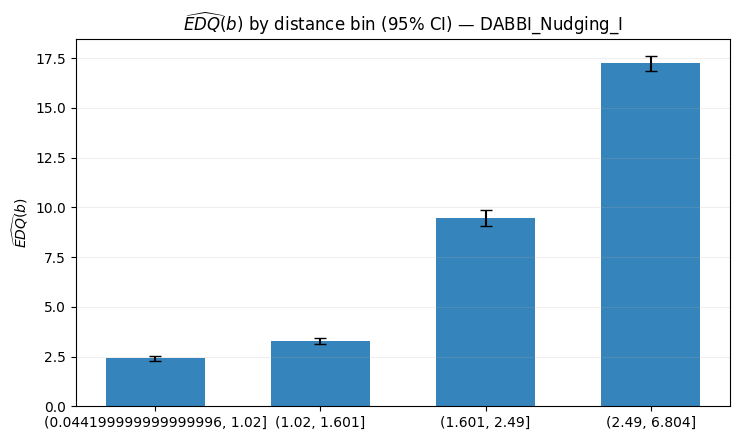

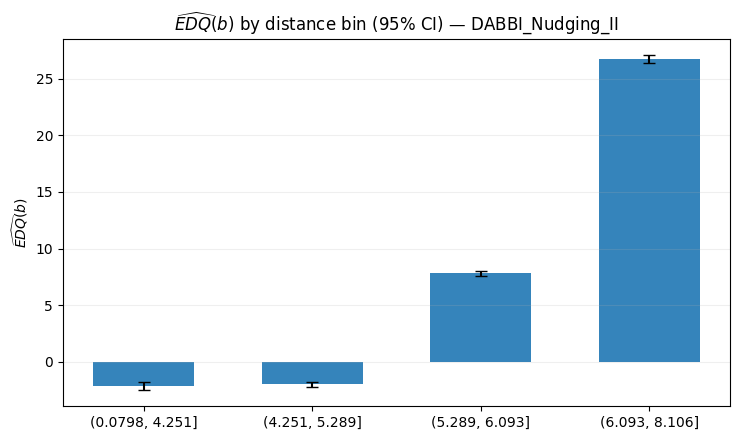

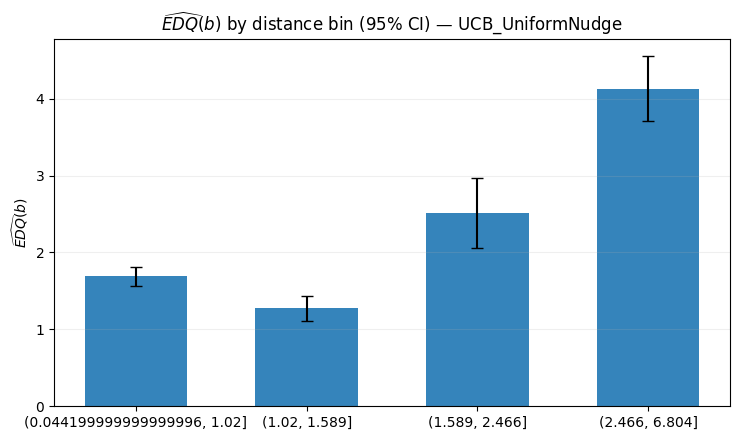

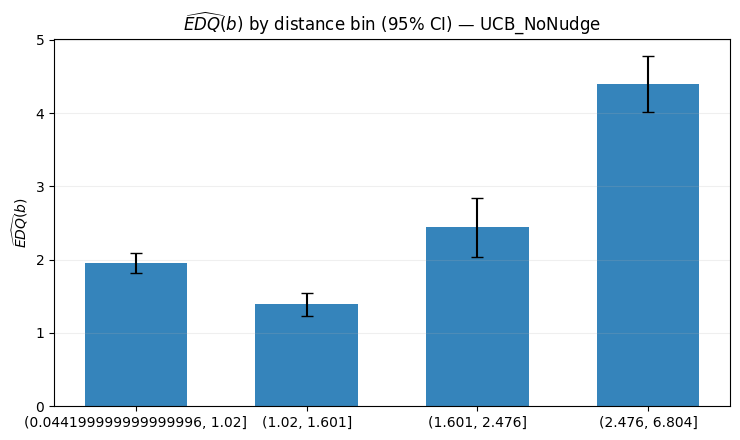

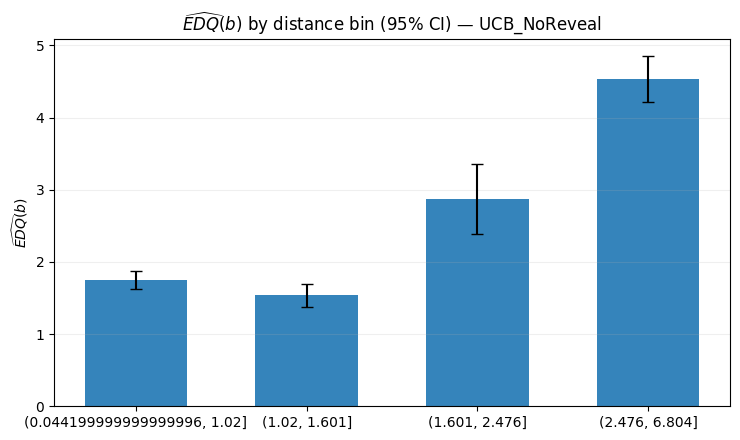

In [1374]:
algorithms = ['DABBI_Nudging_I', 'DABBI_Nudging_II', 'UCB_UniformNudge', 'UCB_NoNudge', 'UCB_NoReveal']

def load_action_disagreement(metrics_path):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    ad = metrics.get('action_disagreement', None)
    if ad is None or not all(k in ad for k in ['EDQ','p_Y','VPN','bin_names']):
        raise ValueError(f"Missing action_disagreement in {metrics_path}")
    return np.asarray(ad['EDQ']), ad['bin_names']  # EDQ: [seed, user, bin]

def aggregate_seed_level_edq(edq_tensor):
    # edq_tensor: [S, U, B]
    seed_means = edq_tensor.mean(axis=1)          # [S, B] mean over users within seed
    mean_bins  = seed_means.mean(axis=0)          # [B]   mean over seeds
    S = seed_means.shape[0]
    if S > 1:
        std_bins = seed_means.std(axis=0, ddof=1)
        sem_bins = std_bins / np.sqrt(S)
        ci95_bins = 1.96 * sem_bins
    else:
        ci95_bins = np.zeros_like(mean_bins)
    return mean_bins, ci95_bins

def plot_edq_bars(mean_edq, ci_edq, bin_names, title_suffix=''):
    x = np.arange(len(bin_names))
    plt.figure(figsize=(7.5, 4.5))
    plt.bar(x, mean_edq, yerr=ci_edq, width=0.6, capsize=4, alpha=0.9)
    plt.xticks(x, bin_names)
    # plt.xlabel('Distance bins {Q1, Q2, Q3}')
    plt.ylabel(r'$\widehat{EDQ}(b)$')
    plt.title(r'$\widehat{EDQ}(b)$ by distance bin (95% CI)' + title_suffix)
    plt.grid(axis='y', alpha=0.2)
    plt.tight_layout()
    plt.show()

# Plot per algorithm (or set algorithms = [one name] to plot just one)
for alg in algorithms:
    mp = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(mp):
        print(f"Skipping {alg}: not found -> {mp}")
        continue
    EDQ, bin_names = load_action_disagreement(mp)
    mean_edq, ci_edq = aggregate_seed_level_edq(EDQ)
    plot_edq_bars(mean_edq, ci_edq, bin_names, title_suffix=f' — {alg}')

Processing DABBI_Nudging_I...


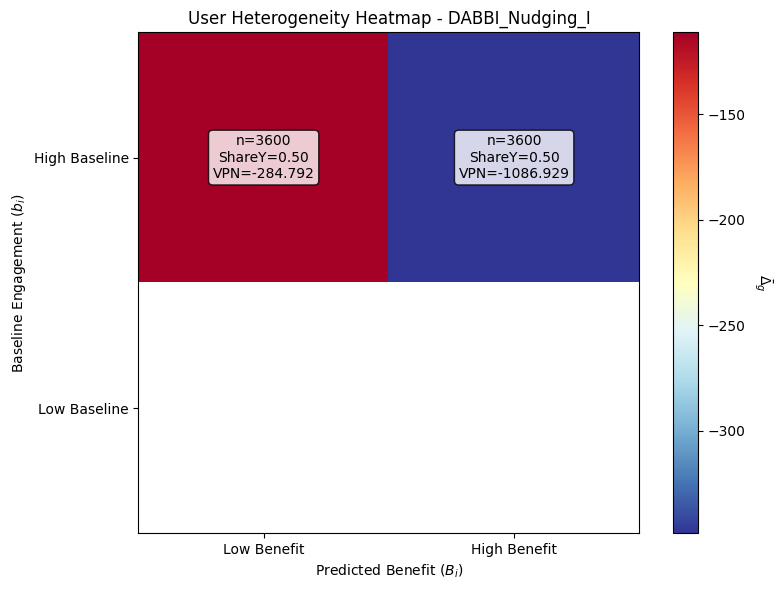

Processing DABBI_Nudging_II...


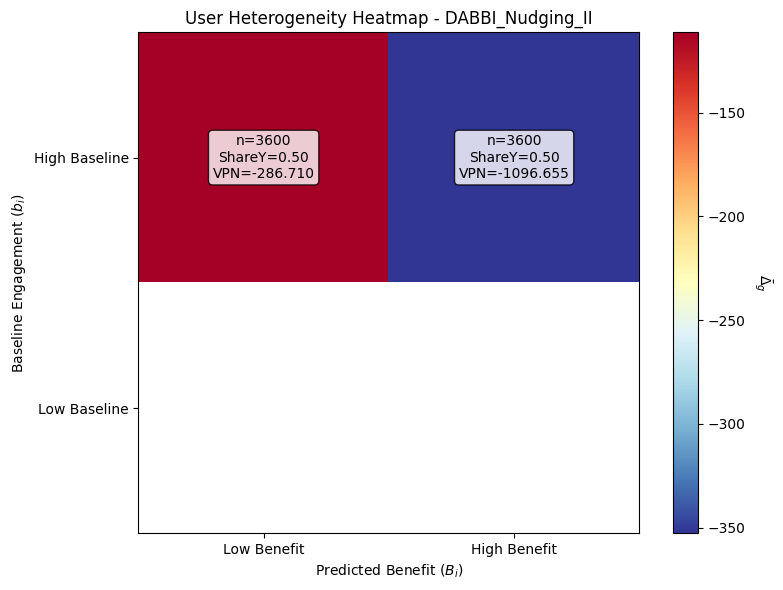

Processing UCB_UniformNudge...


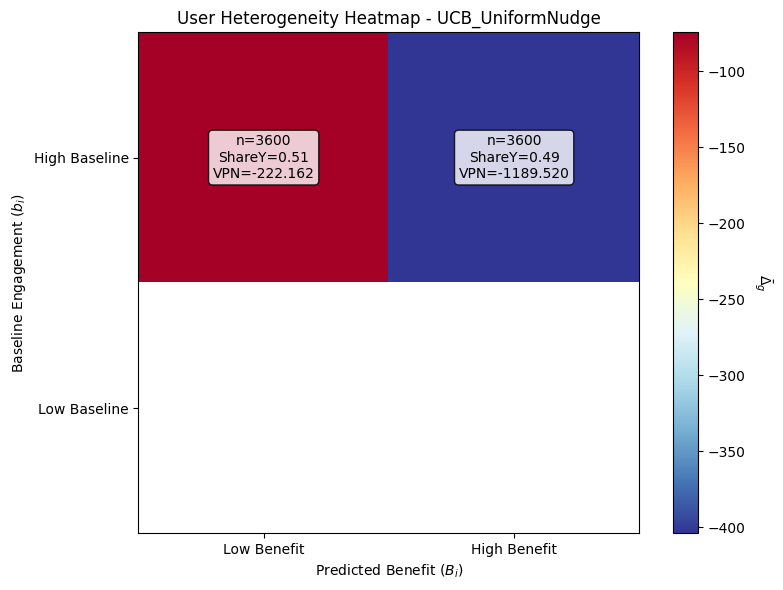

Processing UCB_NoNudge...


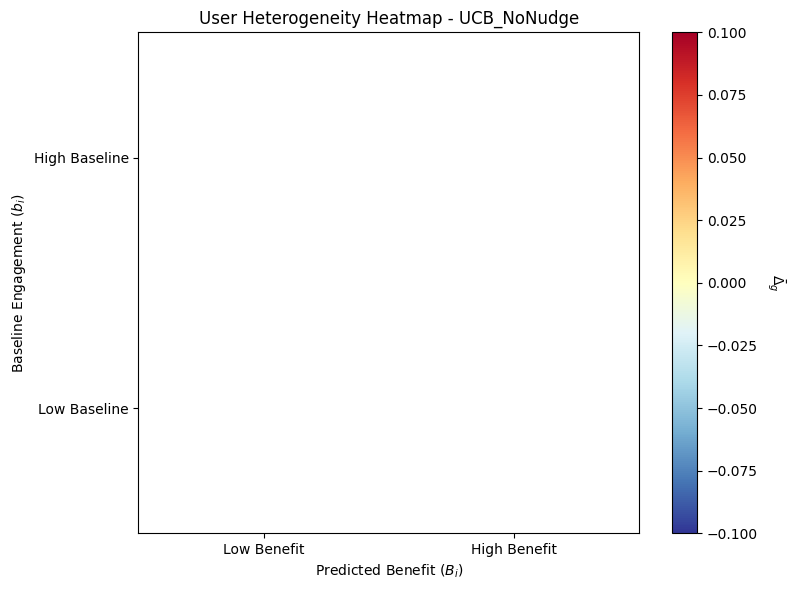

Processing UCB_NoReveal...


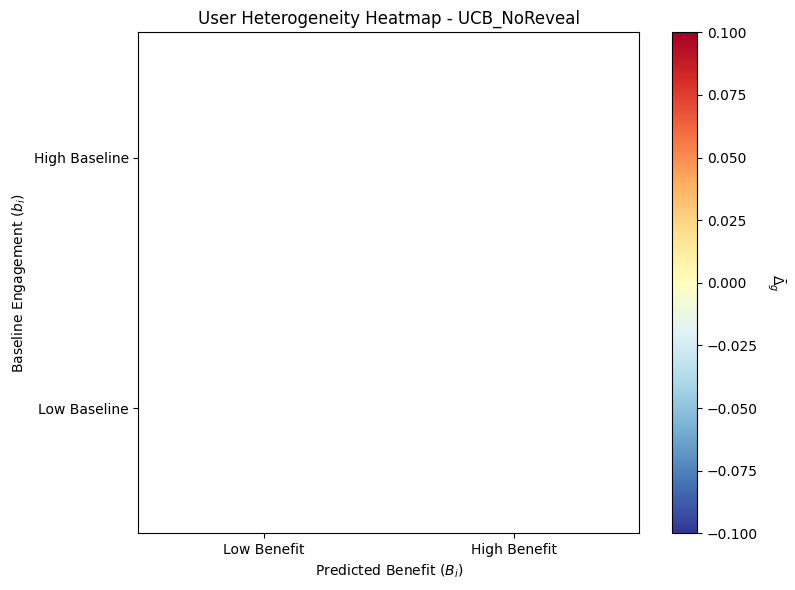

In [1375]:
algorithms = ['DABBI_Nudging_I', 'DABBI_Nudging_II', 'UCB_UniformNudge', 'UCB_NoNudge', 'UCB_NoReveal']

def load_user_heterogeneity(metrics_path):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    
    user_heterogeneity = metrics.get('user_heterogeneity', None)
    if user_heterogeneity is None:
        raise ValueError(f"Missing 'user_heterogeneity' in {metrics_path}")
    
    return user_heterogeneity

def create_heterogeneity_heatmap(user_heterogeneity, algorithm_name):
    """
    Create 2x2 heatmap: baseline (low/high) vs predicted benefit (low/high)
    """
    classification = user_heterogeneity['classification']
    cell_summaries = classification['cell_summaries']
    
    # Create 2x2 grid
    heatmap_data = np.full((2, 2), np.nan)
    annotations = np.full((2, 2), '', dtype=object)
    
    # Map cell names to grid positions
    cell_to_pos = {
        'LB/LB': (0, 0),  # Low baseline, Low benefit
        'LB/HB': (0, 1),  # Low baseline, High benefit  
        'HB/LB': (1, 0),  # High baseline, Low benefit
        'HB/HB': (1, 1)   # High baseline, High benefit
    }
    
    # Fill heatmap data
    for _, row in cell_summaries.iterrows():
        cell = row['cell']
        if cell in cell_to_pos:
            i, j = cell_to_pos[cell]
            
            # Use mean_delta_g if available, otherwise mean_vpn_g
            # if not np.isnan(row['mean_delta_g']):
            heatmap_data[i, j] = row['mean_delta_g']
            color_label = r'$\bar{\Delta}_g$'
            # else:
            #     heatmap_data[i, j] = row['mean_vpn_g']
            #     color_label = r'$\overline{VPN}_g$'
            
            # Create annotation: n_g, ShareY_g, VPN_g
            n_g = int(row['n_g'])
            share_y = row['share_y_g']
            vpn_g = row['mean_vpn_g']
            
            annotations[i, j] = f'n={n_g}\nShareY={share_y:.2f}\nVPN={vpn_g:.3f}'
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Create heatmap
    im = ax.imshow(heatmap_data, cmap='RdYlBu_r', aspect='equal')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(r'$\bar{\Delta}_g$', rotation=270, labelpad=20)
    
    # Set ticks and labels
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Low Benefit', 'High Benefit'])
    ax.set_yticklabels(['High Baseline', 'Low Baseline'])
    ax.set_xlabel('Predicted Benefit ($B_i$)')
    ax.set_ylabel('Baseline Engagement ($b_i$)')
    
    # Add annotations
    for i in range(2):
        for j in range(2):
            if not np.isnan(heatmap_data[i, j]):
                ax.text(j, i, annotations[i, j], ha='center', va='center', 
                       fontsize=10, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    ax.set_title(f'User Heterogeneity Heatmap - {algorithm_name}')
    plt.tight_layout()
    plt.show()

# Plot heatmap for each algorithm
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    user_heterogeneity = load_user_heterogeneity(metrics_path)
    create_heterogeneity_heatmap(user_heterogeneity, alg)